In [1]:
%%html
<style>
.cell-output-ipywidget-background {
    background-color: transparent !important;
}
:root {
    --jp-widgets-color: var(--vscode-editor-foreground);
    --jp-widgets-font-size: var(--vscode-editor-font-size);
}  
</style>

In [3]:
import torch

from typing import Tuple

import numpy as np
import matplotlib.pyplot as plt
from IPython import display
from tqdm.notebook import tqdm
from rl import RLAgent, ACModel
from rl import update_parameters_ppo, collect_experiences



# Training parameters
MAX_ROLLOUT_LENGTH = 40 # Max 40 moves. Every cube can be solved in 20 moves.
N_TRAINING_EPISODES = 100
N_TRAINING_CUBES = 50
N_ROLLOUTS_PER_TRAINING_CUBE = 10
N_EVAL_CUBES = 50

SMOOTH_REWARD_WINDOW = 50

SCORE_THRESHOLD = 0.8

In [6]:
ac_model = ACModel()

# load pretrained model
# ac_model.load_state_dict(torch.load('ac_model_level_6.pt'))

rl_agent = RLAgent(ac_model, MAX_ROLLOUT_LENGTH)

In [4]:
# First train the actor on a suboptimal dataset, sort of imitation learning
from cube import Cube, moves, moves_idx
from cube_nn import cube_to_tensor_one_hot

from torch.utils.data import Dataset
from torch.nn.functional import one_hot
class SuboptimalDataset(Dataset):

    def __init__(self, n_cubes, n_scrambling_moves=20):
        
        self.data = []
        for _ in tqdm(range(n_cubes), desc="Generating suboptimal dataset"):
            cube = Cube()
            for _ in range(n_scrambling_moves):
                move_idx = np.random.randint(len(moves))
                cube.move(moves[move_idx])
                state_tensor = cube_to_tensor_one_hot(cube).flatten().unsqueeze(0)
                action = torch.tensor(moves_idx[moves[move_idx].get_inverse()], dtype=torch.long)
                self.data.append((state_tensor, action))

    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        return self.data[idx]
    
suboptimal_dataset = SuboptimalDataset(n_cubes=10000)

Generating suboptimal dataset:   0%|          | 0/10000 [00:00<?, ?it/s]

In [7]:
from torch.utils.data import DataLoader
suboptimal_dataloader = DataLoader(suboptimal_dataset, batch_size=64, shuffle=True)

from torch import nn, optim
optimizer = optim.Adam(ac_model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
n_epochs = 10
for epoch in range(n_epochs):
    total_loss = 0
    for states, actions in tqdm(suboptimal_dataloader, desc=f"Epoch {epoch+1}/{n_epochs}"):
        optimizer.zero_grad()
        logits, _ = ac_model(states)
        loss = criterion(logits.squeeze(1), actions)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(suboptimal_dataloader)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.8f}")
    

Epoch 1/10:   0%|          | 0/3125 [00:00<?, ?it/s]

Epoch 1, Loss: 2.70300856


Epoch 2/10:   0%|          | 0/3125 [00:00<?, ?it/s]

Epoch 2, Loss: 2.51178411


Epoch 3/10:   0%|          | 0/3125 [00:00<?, ?it/s]

...

Epoch 8, Loss: 2.09642172


Epoch 9/10:   0%|          | 0/3125 [00:00<?, ?it/s]

Epoch 9, Loss: 2.04546908


Epoch 10/10:   0%|          | 0/3125 [00:00<?, ?it/s]

Epoch 10, Loss: 1.99358634


In [8]:

def try_to_solve(agent: RLAgent, cube: Cube, max_moves: int = 40) -> Tuple[bool, int]:
    """
    Try to solve the cube with the current policy.
    Returns a tuple (solved: bool, n_moves: int)
    """
    cube = cube.copy()
    iter_count = 0

    agent.reset()
    while not cube.is_solved() and iter_count < max_moves - 1:
        iter_count += 1

        move = agent.get_move(cube)
        cube.move(move)

    agent.get_move(cube)  # Register the terminal state
    return cube.is_solved(), iter_count

def evaluate_agent(agent: RLAgent, n_cubes: int, n_scrambling_moves: int, max_moves: int = 40) -> float:
    """
    Evaluate the agent on n_cubes random cubes.
    Returns the success rate.
    """
    successes = 0
    for _ in range(n_cubes):
        cube = Cube()
        cube.scramble(n_scrambling_moves)
        solved, n_moves = try_to_solve(agent, cube, max_moves)
        if solved:
            successes += 1
    return successes / n_cubes


rl_agent.set_to_eval_mode()
succ_rates = []
for n_scrambling_moves in tqdm(range(1, 20)):
    success_rate = evaluate_agent(rl_agent, 100, n_scrambling_moves=n_scrambling_moves, max_moves=40)
    succ_rates.append(success_rate)
    

  0%|          | 0/19 [00:00<?, ?it/s]

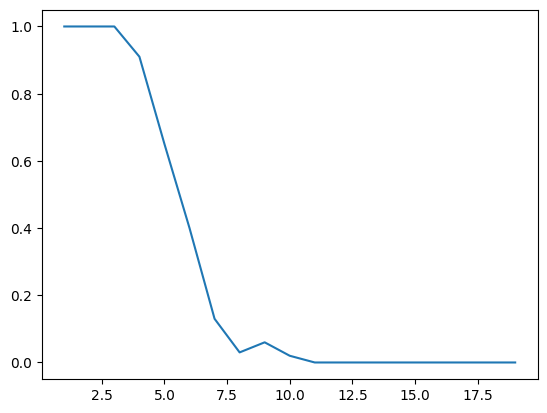

In [9]:
%matplotlib inline


plt.plot(range(1, 20), succ_rates)

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/0.8 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

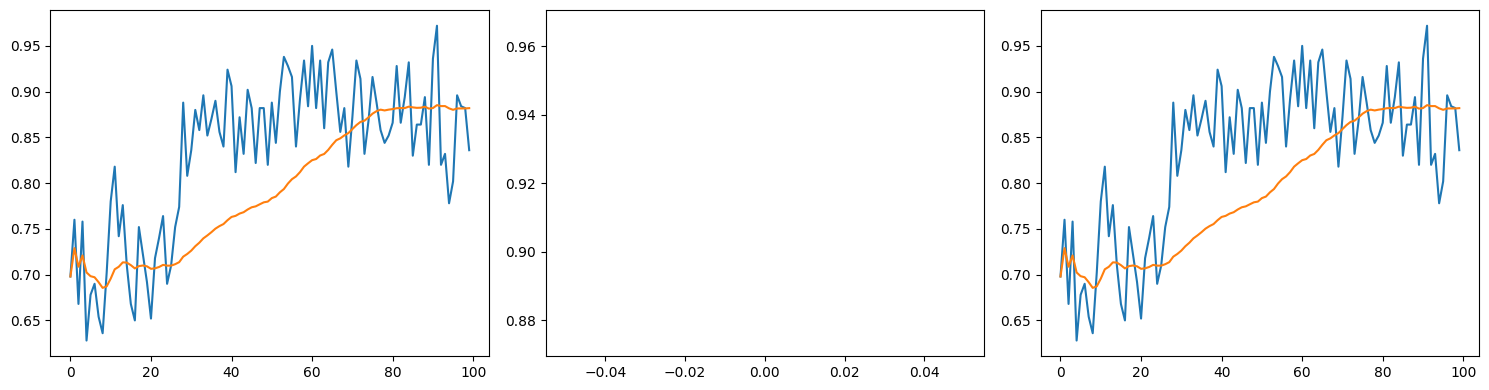

  0%|          | 0/0.8 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [10]:

%matplotlib inline

optimizer = torch.optim.Adam(ac_model.parameters(), lr=1e-3)
rl_agent.set_to_train_mode()

cubes_solved = []
smooth_cubes_solved = []

def train_curriculum(min_moves: int, max_moves: int, seed=0):
    np.random.seed(seed)
    torch.manual_seed(seed)

    pbar_1 = tqdm(range(min_moves, max_moves), leave = None)
    for level in pbar_1:
        num_frames = 0

        level_cubes_solved = []
        level_smooth_cubes_solved = []

        level_eval_cubes_solved = []

        level_passed = False
        max_rollout_length = min(MAX_ROLLOUT_LENGTH, 5 + 2*level)
        n_training_cubes = N_TRAINING_CUBES
        n_rollouts_per_training_cube = N_ROLLOUTS_PER_TRAINING_CUBE

        # if level > 2:
        #     n_training_cubes = 50
        #     n_rollouts_per_training_cube = 1

        pbar_2 = tqdm(total=SCORE_THRESHOLD, leave = None)


        while not level_passed:
            # Training step
            rl_agent.set_to_train_mode()
            pbar_3 = tqdm(range(N_TRAINING_EPISODES), leave = None)
            for episode in pbar_3:
                exps = collect_experiences(rl_agent, n_training_cubes, n_rollouts_per_training_cube, level+1, max_rollout_length)
                logs = update_parameters_ppo(optimizer, rl_agent.ac_model, exps)
            
                num_frames += exps['states'].shape[1]
                episode_cubes_solved = exps['solved'] / (n_training_cubes * n_rollouts_per_training_cube)

                cubes_solved.append(episode_cubes_solved)
                level_cubes_solved.append(episode_cubes_solved)
                
                current_smooth_cubes_solved = float(np.mean(level_cubes_solved[-min(SMOOTH_REWARD_WINDOW, len(level_cubes_solved)):]))
                smooth_cubes_solved.append(current_smooth_cubes_solved)
                level_smooth_cubes_solved.append(current_smooth_cubes_solved)

                data = {'episode':episode, 'num_frames':num_frames, 'smooth_cubes_solved':current_smooth_cubes_solved,
                        'cubes_solved': episode_cubes_solved, 'policy_loss':logs["policy_loss"], 'value_loss':logs["value_loss"]}

                pbar_3.set_postfix(data)
            pbar_3.close()

            # Evaluation step
            rl_agent.set_to_eval_mode()
            eval_exps = collect_experiences(rl_agent, N_EVAL_CUBES, 1, level+1, max_rollout_length)
            eval_cubes_solved = eval_exps['solved'] / N_EVAL_CUBES
            level_eval_cubes_solved.append(eval_cubes_solved)
            pbar_2.n = float(eval_cubes_solved)
            pbar_2.refresh()
            if eval_cubes_solved >= SCORE_THRESHOLD:
                level_passed = True

            # Save the model
            torch.save(ac_model.state_dict(), f'ac_model_level_{level}.pt')
        pbar_2.close()
        
        fig, axs = plt.subplots(1, 3, figsize=(15, 4))
        axs[0].plot(level_cubes_solved)
        axs[0].plot(level_smooth_cubes_solved)
        axs[1].plot(level_eval_cubes_solved)
        axs[2].plot(cubes_solved)
        axs[2].plot(smooth_cubes_solved)
        plt.tight_layout()
        plt.show()

train_curriculum(3,8)